setup

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from feature_store.engineer import build_features, get_feature_columns
from feature_store.sources.weather import generate_simulated_weather
from model.evaluate import compute_wmape

DATA_RAW = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\store-sales-time-series-forecasting")

train = pd.read_csv(DATA_RAW / "train.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_RAW / "holidays_events.csv", parse_dates=["date"])
stores_info = pd.read_csv(DATA_RAW / "stores.csv")
weather = generate_simulated_weather(train["date"].sort_values().unique())

SPLIT_DATE = "2017-07-15"

print(f"Total stores: {train.store_nbr.nunique()}")
print(f"Total categories: {train.family.nunique()}")
print(f"Categories: {sorted(train.family.unique())}")

Total stores: 54
Total categories: 33
Categories: ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


building a function which trains and evaluates any store+category combo:

In [2]:
def evaluate_category(store_data, category, holidays, weather):
    """
    Train XGBoost and baseline for one store+category.
    Returns dict with results, or None if not enough data.
    """
    cat_data = (store_data[store_data.family == category]
                .sort_values("date").reset_index(drop=True))
    
    # Skip if too little data
    if len(cat_data) < 100:
        return None
    
    # Skip if almost no sales (can't learn from zeros)
    if cat_data["sales"].sum() < 50:
        return None
    
    try:
        features = build_features(cat_data, holidays, weather_df=weather).dropna()
        feat_cols = get_feature_columns(features)
        
        train_df = features[features.index < SPLIT_DATE]
        test_df = features[features.index >= SPLIT_DATE]
        
        # Need enough data in both splits
        if len(train_df) < 50 or len(test_df) < 5:
            return None
        
        # Skip if test period has no sales
        if test_df["sales"].sum() == 0:
            return None
        
        X_train = train_df[feat_cols]
        y_train = train_df["sales"]
        X_test = test_df[feat_cols]
        y_test = test_df["sales"]
        
        # Baseline: 4-week same-day-of-week average
        baseline_pred = test_df["sales_same_dow_avg_4w"].fillna(0).values
        baseline_wmape = compute_wmape(y_test.values, baseline_pred)
        
        # XGBoost
        model = xgb.XGBRegressor(
            objective="reg:tweedie", tweedie_variance_power=1.6,
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
            reg_alpha=0.1, reg_lambda=1.0, random_state=42,
            early_stopping_rounds=30)
        
        model.fit(X_train, y_train, 
                  eval_set=[(X_test, y_test)], verbose=False)
        
        predictions = np.maximum(model.predict(X_test), 0)
        xgb_wmape = compute_wmape(y_test.values, predictions)
        
        improvement = (baseline_wmape - xgb_wmape) / baseline_wmape * 100
        
        return {
            "category": category,
            "baseline_wmape": round(baseline_wmape, 4),
            "xgb_wmape": round(xgb_wmape, 4),
            "improvement_pct": round(improvement, 1),
            "avg_daily_sales": round(y_test.mean(), 1),
            "test_days": len(y_test),
            "zero_pct": round((cat_data["sales"] == 0).mean() * 100, 1),
        }
    
    except Exception as e:
        print(f"  Error on {category}: {e}")
        return None

Testing ALL categories at Store 44:

In [5]:
# This will take a few minutes — it's training 33 separate models
store44 = train[train.store_nbr == 44]
categories = sorted(store44.family.unique())

print(f"Testing {len(categories)} categories at Store 44...")
print("This takes a few minutes — training one model per category.\n")

results = []
for i, cat in enumerate(categories):
    print(f"  [{i+1}/{len(categories)}] {cat}...", end=" ")
    result = evaluate_category(store44, cat, holidays, weather)
    if result:
        beat = "✅" if result["improvement_pct"] > 0 else "❌"
        print(f"WMAPE: {result['xgb_wmape']:.1%} {beat}")
        results.append(result)
    else:
        print("⏭️  Skipped (not enough data)")

results_df = pd.DataFrame(results).sort_values("xgb_wmape")
print(f"\nSuccessfully tested: {len(results)} out of {len(categories)} categories")

Testing 33 categories at Store 44...
This takes a few minutes — training one model per category.

  [1/33] AUTOMOTIVE... WMAPE: 27.3% ✅
  [2/33] BABY CARE... ⏭️  Skipped (not enough data)
  [3/33] BEAUTY... WMAPE: 23.3% ❌
  [4/33] BEVERAGES... WMAPE: 13.0% ✅
  [5/33] BOOKS... WMAPE: 299.1% ✅
  [6/33] BREAD/BAKERY... WMAPE: 6.5% ✅
  [7/33] CELEBRATION... WMAPE: 27.9% ✅
  [8/33] CLEANING... WMAPE: 13.7% ✅
  [9/33] DAIRY... WMAPE: 6.4% ✅
  [10/33] DELI... WMAPE: 10.9% ✅
  [11/33] EGGS... WMAPE: 6.0% ✅
  [12/33] FROZEN FOODS... WMAPE: 11.5% ❌
  [13/33] GROCERY I... WMAPE: 9.3% ✅
  [14/33] GROCERY II... WMAPE: 22.2% ✅
  [15/33] HARDWARE... WMAPE: 43.8% ✅
  [16/33] HOME AND KITCHEN I... WMAPE: 25.0% ✅
  [17/33] HOME AND KITCHEN II... WMAPE: 17.3% ✅
  [18/33] HOME APPLIANCES... WMAPE: 180.3% ✅
  [19/33] HOME CARE... WMAPE: 14.8% ✅
  [20/33] LADIESWEAR... WMAPE: 30.9% ✅
  [21/33] LAWN AND GARDEN... WMAPE: 26.7% ✅
  [22/33] LINGERIE... WMAPE: 63.3% ✅
  [23/33] LIQUOR,WINE,BEER... WMAPE: 15.5% ✅

results table

In [6]:
# Pretty print the results
print("=" * 85)
print("  STORE 44 — ALL CATEGORIES — XGBoost vs Baseline")
print("=" * 85)
print(f"  {'Category':<25s} {'Baseline':>10s} {'XGBoost':>10s} {'Improve':>10s} {'Avg Sales':>10s} {'Zero%':>8s}")
print("-" * 85)

beats_baseline = 0
for _, row in results_df.iterrows():
    beat = "✅" if row["improvement_pct"] > 0 else "❌"
    print(f"  {row['category']:<25s} {row['baseline_wmape']:>9.1%} {row['xgb_wmape']:>9.1%} {row['improvement_pct']:>+9.1f}% {row['avg_daily_sales']:>10.0f} {row['zero_pct']:>7.1f}%")
    if row["improvement_pct"] > 0:
        beats_baseline += 1

print("-" * 85)
avg_baseline = results_df["baseline_wmape"].mean()
avg_xgb = results_df["xgb_wmape"].mean()
avg_improve = results_df["improvement_pct"].mean()
print(f"  {'AVERAGE':<25s} {avg_baseline:>9.1%} {avg_xgb:>9.1%} {avg_improve:>+9.1f}%")
print(f"\n  XGBoost beats baseline in {beats_baseline}/{len(results)} categories ({beats_baseline/len(results)*100:.0f}%)")

  STORE 44 — ALL CATEGORIES — XGBoost vs Baseline
  Category                    Baseline    XGBoost    Improve  Avg Sales    Zero%
-------------------------------------------------------------------------------------
  EGGS                           7.5%      6.0%     +19.5%        649     0.3%
  DAIRY                          9.4%      6.4%     +31.7%       2550     0.3%
  BREAD/BAKERY                  10.2%      6.5%     +36.4%       1644     0.3%
  PRODUCE                        7.2%      7.0%      +2.8%       9656     4.8%
  MEATS                         10.7%      7.6%     +28.4%        950     0.3%
  POULTRY                       10.5%      8.8%     +16.4%       1232     0.3%
  GROCERY I                     10.7%      9.3%     +12.7%      10184     0.3%
  PREPARED FOODS                 9.2%     10.0%      -8.2%        308     0.3%
  DELI                          11.5%     10.9%      +4.3%        590     0.3%
  FROZEN FOODS                  11.3%     11.5%      -1.6%        463   

comparing visuals

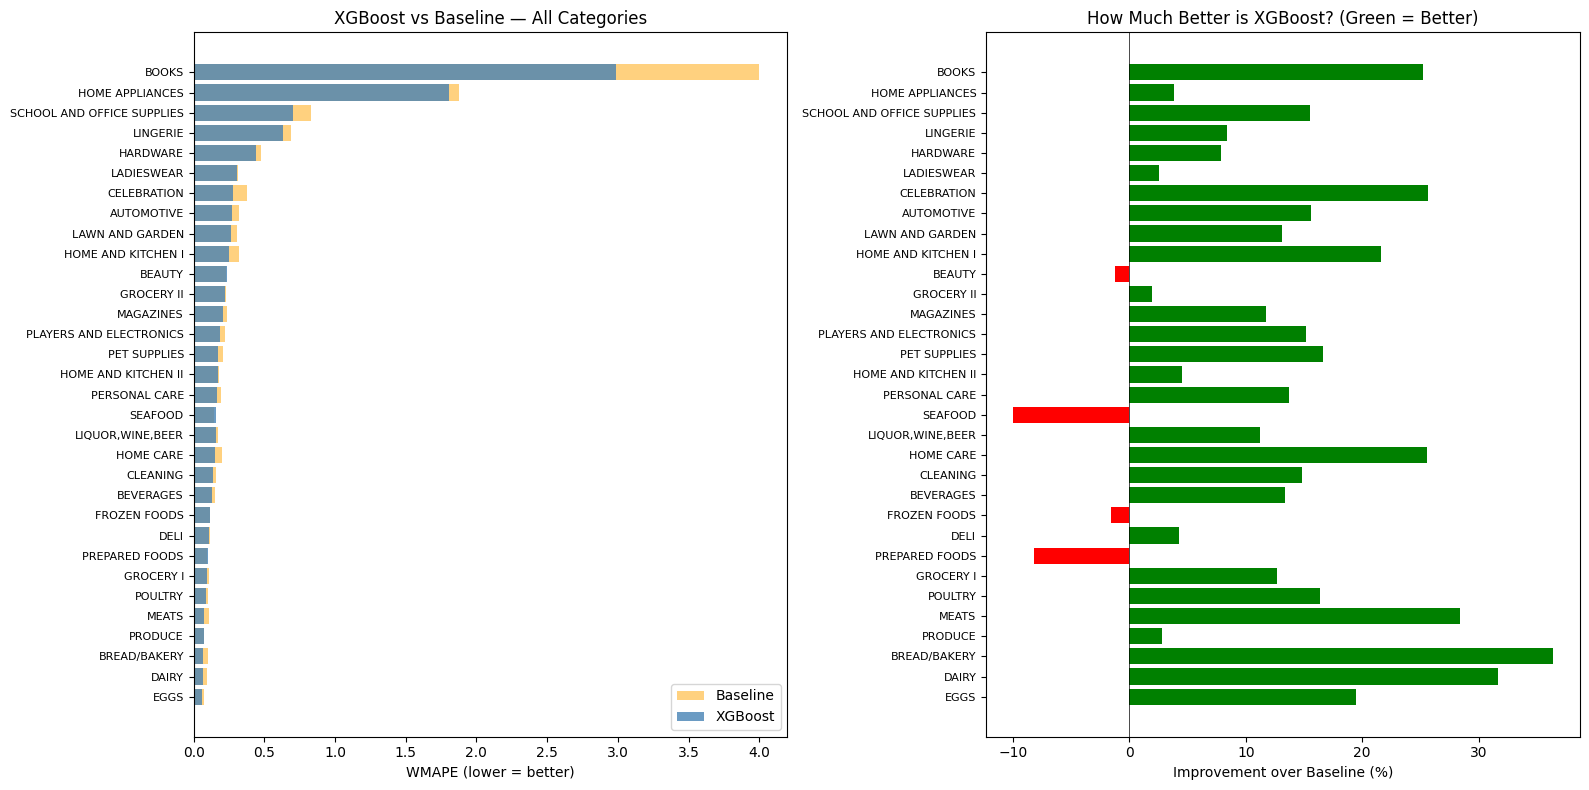

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: WMAPE comparison by category
plot_df = results_df.sort_values("xgb_wmape", ascending=True)

y_pos = range(len(plot_df))
axes[0].barh(y_pos, plot_df["baseline_wmape"].values, 
             alpha=0.5, color="orange", label="Baseline")
axes[0].barh(y_pos, plot_df["xgb_wmape"].values, 
             alpha=0.8, color="steelblue", label="XGBoost")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(plot_df["category"].values, fontsize=8)
axes[0].set_xlabel("WMAPE (lower = better)")
axes[0].set_title("XGBoost vs Baseline — All Categories")
axes[0].legend()

# Chart 2: Improvement percentage
colors = ["green" if x > 0 else "red" for x in plot_df["improvement_pct"].values]
axes[1].barh(y_pos, plot_df["improvement_pct"].values, color=colors)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(plot_df["category"].values, fontsize=8)
axes[1].set_xlabel("Improvement over Baseline (%)")
axes[1].set_title("How Much Better is XGBoost? (Green = Better)")
axes[1].axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

testing across multiple stores

In [8]:
# Test the top 5 categories across 10 different stores
# This shows whether the model generalizes beyond Store 44

test_stores = [3, 10, 20, 30, 44, 47, 50, 52, 53, 54]
test_categories = ["BEVERAGES", "GROCERY I", "PRODUCE", "DAIRY", "MEATS"]

print(f"Testing {len(test_categories)} categories across {len(test_stores)} stores...")
print("This will take several minutes.\n")

multi_store_results = []

for store_num in test_stores:
    store_data = train[train.store_nbr == store_num]
    print(f"Store {store_num}:")
    
    for cat in test_categories:
        result = evaluate_category(store_data, cat, holidays, weather)
        if result:
            result["store"] = store_num
            multi_store_results.append(result)
            beat = "✅" if result["improvement_pct"] > 0 else "❌"
            print(f"  {cat:<15s} → {result['xgb_wmape']:.1%} {beat}")
        else:
            print(f"  {cat:<15s} → ⏭️ Skipped")
    print()

multi_df = pd.DataFrame(multi_store_results)
print(f"Total models trained: {len(multi_df)}")

Testing 5 categories across 10 stores...
This will take several minutes.

Store 3:
  BEVERAGES       → 9.8% ❌
  GROCERY I       → 6.4% ✅
  PRODUCE         → 5.5% ✅
  DAIRY           → 5.2% ✅
  MEATS           → 8.2% ✅

Store 10:
  BEVERAGES       → 15.5% ❌
  GROCERY I       → 8.6% ✅
  PRODUCE         → 12.8% ✅
  DAIRY           → 15.8% ✅
  MEATS           → 12.8% ❌

Store 20:
  BEVERAGES       → 16.3% ❌
  GROCERY I       → 13.8% ✅
  PRODUCE         → 11.1% ❌
  DAIRY           → 9.5% ✅
  MEATS           → 14.5% ❌

Store 30:
  BEVERAGES       → 26.7% ✅
  GROCERY I       → 24.9% ✅
  PRODUCE         → 14.1% ❌
  DAIRY           → 12.7% ❌
  MEATS           → 15.7% ✅

Store 44:
  BEVERAGES       → 13.0% ✅
  GROCERY I       → 9.3% ✅
  PRODUCE         → 7.0% ✅
  DAIRY           → 6.4% ✅
  MEATS           → 7.6% ✅

Store 47:
  BEVERAGES       → 10.9% ✅
  GROCERY I       → 10.2% ✅
  PRODUCE         → 7.2% ✅
  DAIRY           → 7.0% ✅
  MEATS           → 8.1% ✅

Store 50:
  BEVERAGES       → 10.7%

summary across all stores

  XGBoost WMAPE ACROSS STORES AND CATEGORIES
category BEVERAGES  DAIRY GROCERY I  MEATS PRODUCE
store                                             
3             9.8%   5.2%      6.4%   8.2%    5.5%
10           15.5%  15.8%      8.6%  12.8%   12.8%
20           16.3%   9.5%     13.8%  14.5%   11.1%
30           26.7%  12.7%     24.9%  15.7%   14.1%
44           13.0%   6.4%      9.3%   7.6%    7.0%
47           10.9%   7.0%     10.2%   8.1%    7.2%
50           10.7%   6.9%      9.5%  11.0%    7.4%
52           12.6%  12.9%     14.8%  11.6%   10.3%
53           11.9%  11.1%      8.5%  12.0%    6.1%
54           29.6%  11.7%     12.0%  15.9%    9.2%

  Overall average WMAPE: 11.6%
  Best performing: Store 3, DAIRY (5.2%)
  Worst performing: Store 54, BEVERAGES (29.6%)

  XGBoost beats baseline: 35/50 (70%)


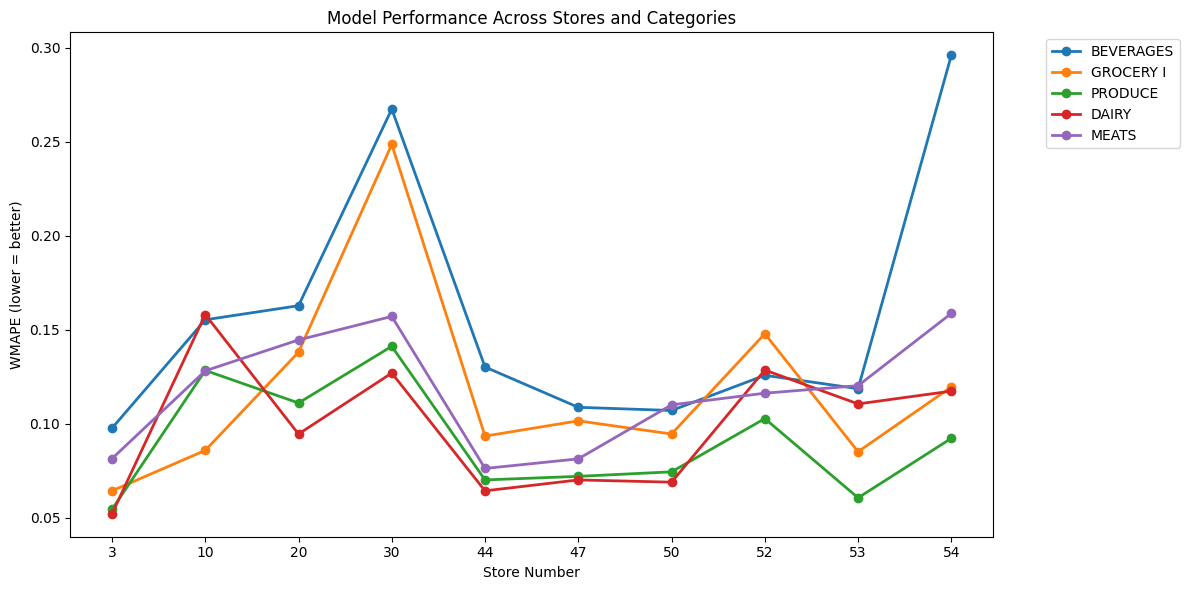

In [9]:
# Pivot table: stores as rows, categories as columns
print("=" * 70)
print("  XGBoost WMAPE ACROSS STORES AND CATEGORIES")
print("=" * 70)

pivot = multi_df.pivot_table(
    index="store", 
    columns="category", 
    values="xgb_wmape"
)

# Format as percentages
print(pivot.map(lambda x: f"{x:.1%}" if pd.notna(x) else "—").to_string())

print(f"\n  Overall average WMAPE: {multi_df['xgb_wmape'].mean():.1%}")
print(f"  Best performing: Store {multi_df.loc[multi_df['xgb_wmape'].idxmin(), 'store']}, "
      f"{multi_df.loc[multi_df['xgb_wmape'].idxmin(), 'category']} "
      f"({multi_df['xgb_wmape'].min():.1%})")
print(f"  Worst performing: Store {multi_df.loc[multi_df['xgb_wmape'].idxmax(), 'store']}, "
      f"{multi_df.loc[multi_df['xgb_wmape'].idxmax(), 'category']} "
      f"({multi_df['xgb_wmape'].max():.1%})")

# How often does XGBoost beat baseline?
beat_count = (multi_df["improvement_pct"] > 0).sum()
print(f"\n  XGBoost beats baseline: {beat_count}/{len(multi_df)} ({beat_count/len(multi_df)*100:.0f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
for cat in test_categories:
    cat_data = multi_df[multi_df["category"] == cat]
    ax.plot(cat_data["store"].astype(str), cat_data["xgb_wmape"], 
            marker="o", label=cat, linewidth=2)

ax.set_xlabel("Store Number")
ax.set_ylabel("WMAPE (lower = better)")
ax.set_title("Model Performance Across Stores and Categories")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()